**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [2]:
filepath = "./audio/Guitar-string-plucked-at-headstock.wav"
ref, fs = load_audio(filepath)
ipd.Audio(ref, rate=fs)

plot_signals(ref,fs, 0, 1)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

In [3]:
from scipy.signal import spectrogram

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [21]:
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 4000.0)

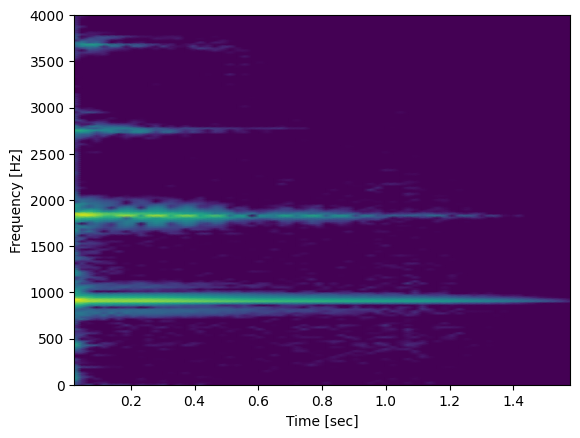

In [19]:
window_length = 2048
ff, tt, S = spectrogram(ref, fs, nperseg  = window_length, noverlap= window_length//2) 
plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])


1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [77]:
plot_spectrum_at(ff, tt, S, 0.14)


1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [111]:
weights = [1, 0.5594, 0.07859, 0.06199, 0.1524, 0.04914, 0.04642, 0.02122, 0.008588, 0.01908]

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [108]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

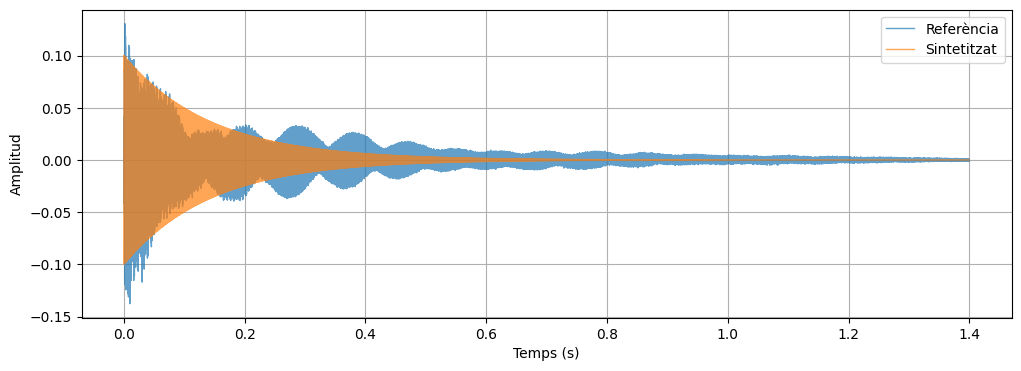

Senyal sintetitzat:


In [127]:
f0 = 904.39  #freq fonamental
phi = 0
A_ref = 0.1  # amplitud de referència

# Crea el vector de temps (mateix que el senyal de referència)
t = np.arange(len(ref)) / fs

Ak = np.array(weights)
y_synt = synthesize(f0, phi, Ak, t)

decay_rate = 7  # controla la velocitat de decadència
envolvent = np.exp(-decay_rate * t)
y_synt *= envolvent

# normalitza per tenir la mateixa amplitud màxima que la referència
if np.max(np.abs(y_synt)) > 0:
    y_synt = A_ref * y_synt / np.max(np.abs(y_synt))

duration = 1.4
samples = int(duration * fs)

plt.figure(figsize=(12, 4))
plt.plot(t[:samples], ref[:samples], label='Referència', alpha=0.7, linewidth=1)
plt.plot(t[:samples], y_synt[:samples], label='Sintetitzat', alpha=0.7, linewidth=1)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

# Escolta el senyal sintetitzat
print("Senyal sintetitzat:")
ipd.display(ipd.Audio(y_synt, rate=fs))

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

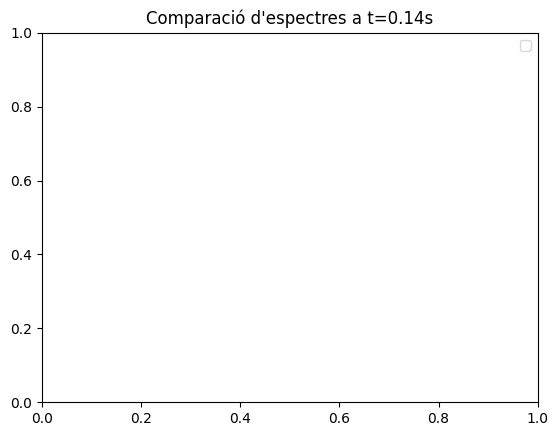

In [128]:
# Calcula l'espectrograma del senyal sintetitzat (mateix window_length que abans!)
ff_synt, tt_synt, S_synt = spectrogram(y_synt, fs, nperseg=window_length, noverlap=window_length//2)

# Compara els espectres al mateix temps que vas triar abans
time_selected = 0.14  # Usa el mateix temps de l'exercici 1.2
plot_spectrum_at(ff, tt, [S, S_synt], time_selected)
plt.legend(['Referència', 'Sintetitzat'])
plt.title(f'Comparació d\'espectres a t={time_selected}s')
plt.show()

2.3. Compare the spectrograms of the two signals. What are the main differences?

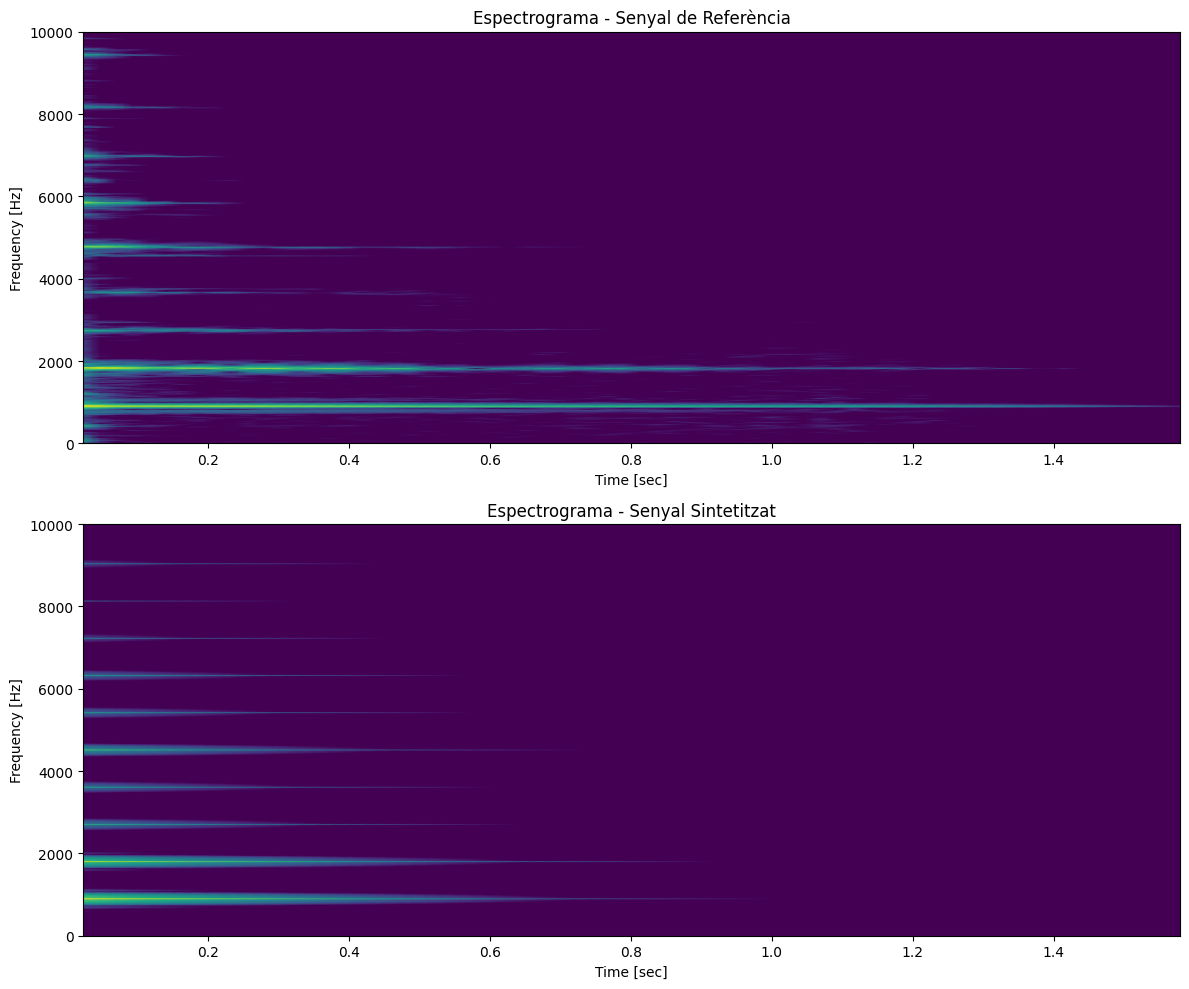

In [129]:
# Plota els dos espectrogrames per veure les diferències
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Espectrograma de referència
plt.sca(axes[0])
plot_spectrogram(ff, tt, S)
plt.ylim([0, 10000])
plt.title('Espectrograma - Senyal de Referència')

# Espectrograma sintetitzat
plt.sca(axes[1])
plot_spectrogram(ff_synt, tt_synt, S_synt)
plt.ylim([0, 10000])
plt.title('Espectrograma - Senyal Sintetitzat')

plt.tight_layout()
plt.show()

En l'espectrograma veiem que el senyal sintetitzat té línies horitzontals casi perfectes i el de referència encara té alguna variació o imperfecció. Els dos decauen amb el temps però el sintetitzat ho fa de manera molt més uniforme i predictible que el de referència. El senyal sintetitzat està format a base dels harmònics que estan especificats però el de referència en pot tenir molts més que no s'han tingut en compte per la sintetització. Els harmònics del senyal sintetitzat són estables en freqüència i els de referència no, ja que hi han variacions.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [130]:
print("SENYAL DE REFERÈNCIA:")
ipd.display(ipd.Audio(ref, rate=fs))

print("SENYAL SINTETITZAT:")
ipd.display(ipd.Audio(y_synt, rate=fs))

SENYAL DE REFERÈNCIA:


SENYAL SINTETITZAT:


Ara els l'audio sintetitzat s'assembla més al de referència que al lab 2 però encara no és prou similar. El sintetitzat encara sona massa artificial o electrònic i sembla que s'acaba bruscament i l'altre és més natural. Encara que la representació s'ha fet amb els harmònics principals, el senyal sintetitzat encara no reprodueix completament la riquesa i naturalitat del so original. El senyal de referència té soroll que no està present al sintetitzat que afegeix realisme.